In [2]:
pip install matplotlib

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------  9.2/9.3 MB 51.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 38.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 39.7 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\DEV\dp_312\.venv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
# 1. 라이브러리 불러오기 및 한글 깨짐 방지 설정
# Matplotlib은 기본적으로 한글 폰트를 지원하지 않기 때문에, 차트에 한글이 들어가면 사각형(ㅁ)으로 깨지는 현상이 발생합니다. 이를 방지하기 위한 설정 코드를 먼저 실행해야 합니다.

import matplotlib.pyplot as plt
import numpy as np

# 한글 깨짐 방지 설정 (윈도우 기준: Malgun Gothic / 맥 기준: AppleGothic)
plt.rc('font', family='Malgun Gothic')

# 마이너스 부호(-) 깨짐 방지
plt.rc('axes', unicode_minus=False)

Matplotlib is building the font cache; this may take a moment.


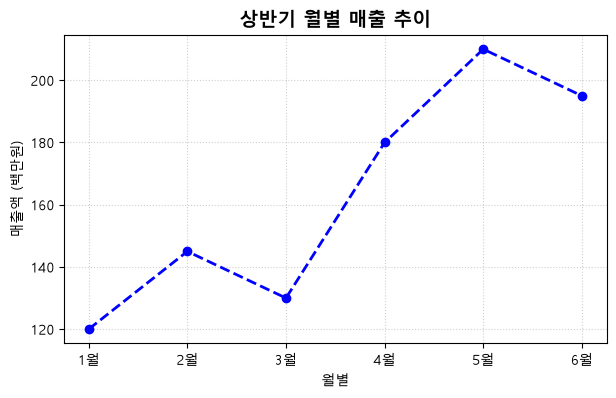

In [4]:
# 2. 4대 기초 그래프 작성 예제
# ① 선 그래프 (Line Plot)
# 시간의 흐름에 따른 데이터의 연속적인 변화 추이를 나타낼 때 가장 적합합니다.

# 데이터 준비
months = ['1월', '2월', '3월', '4월', '5월', '6월']
sales = [120, 145, 130, 180, 210, 195]

# 그래프 생성
plt.figure(figsize=(7, 4)) # 그래프 크기 설정 (가로, 세로 인치)
plt.plot(months, sales, color='blue', marker='o', linestyle='--', linewidth=2)

# 타이틀 및 축 이름 설정
plt.title('상반기 월별 매출 추이', fontsize=14, fontweight='bold')
plt.xlabel('월별')
plt.ylabel('매출액 (백만원)')

# 그리드(격자) 추가 및 출력
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

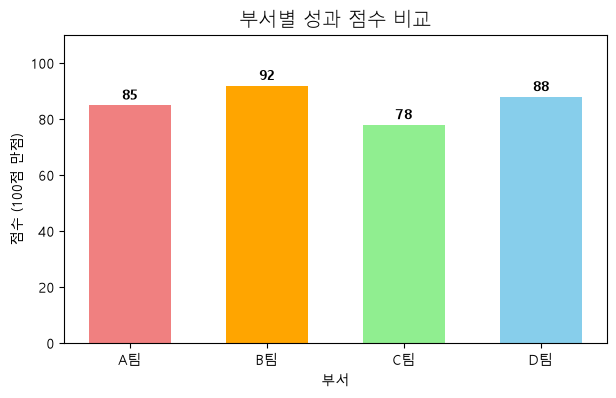

In [5]:
# ② 막대 그래프 (Bar Chart)
# 서로 다른 그룹이나 범주 간의 크기를 비교할 때 직관적이고 효과적입니다.

# 데이터 준비
categories = ['A팀', 'B팀', 'C팀', 'D팀']
scores = [85, 92, 78, 88]

plt.figure(figsize=(7, 4))
# 막대 그래프 그리기 (색상은 리스트로 개별 지정도 가능)
plt.bar(categories, scores, color=['lightcoral', 'orange', 'lightgreen', 'skyblue'], width=0.6)

plt.title('부서별 성과 점수 비교', fontsize=14)
plt.xlabel('부서')
plt.ylabel('점수 (100점 만점)')
plt.ylim(0, 110) # y축 범위 제한 (데이터를 더 돋보이게 조절)

# 각 막대 위에 숫자 값 표시하기
for i, v in enumerate(scores):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

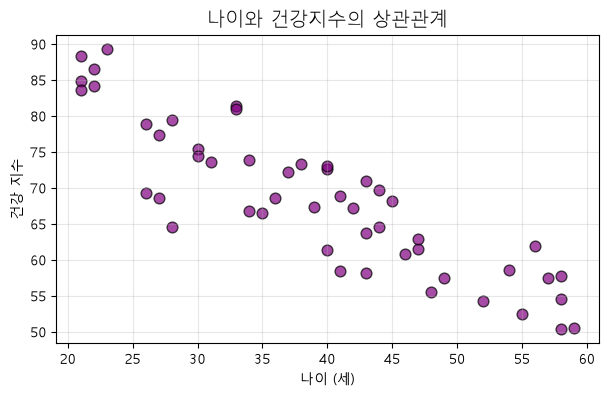

In [6]:
# ③ 산점도 (Scatter Plot)
# 두 연속형 변수 간의 상관관계나 데이터의 분포 패턴을 확인하고자 할 때 사용합니다.

# 데이터 준비 (무작위 나이와 건강지수 데이터 생성)
np.random.seed(42)
age = np.random.randint(20, 60, size=50)
health_index = 100 - (age * 0.8) + np.random.normal(0, 5, size=50) # 나이가 많을수록 건강지수가 낮아지는 관계

plt.figure(figsize=(7, 4))
# s는 마커 크기, c는 색상 배열이나 단일 색상, alpha는 투명도(데이터 중첩 확인용)
plt.scatter(age, health_index, color='purple', s=60, alpha=0.7, edgecolors='black')

plt.title('나이와 건강지수의 상관관계', fontsize=14)
plt.xlabel('나이 (세)')
plt.ylabel('건강 지수')
plt.grid(True, alpha=0.3)
plt.show()

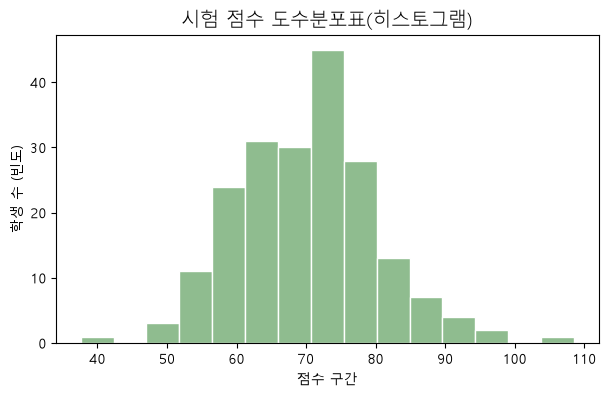

In [7]:
# ④ 히스토그램 (Histogram)
# 단일 연속형 변수의 데이터가 어느 구간에 얼마나 몰려있는지(빈도 분포) 파악할 때 유용합니다.

# 데이터 준비 (평균 70, 표준편차 10인 정규분포를 따르는 시험 점수 200개)
exam_scores = np.random.normal(70, 10, size=200)

plt.figure(figsize=(7, 4))
# bins는 구간의 개수를 의미합니다.
plt.hist(exam_scores, bins=15, color='darkseagreen', edgecolor='white')

plt.title('시험 점수 도수분포표(히스토그램)', fontsize=14)
plt.xlabel('점수 구간')
plt.ylabel('학생 수 (빈도)')
plt.show()

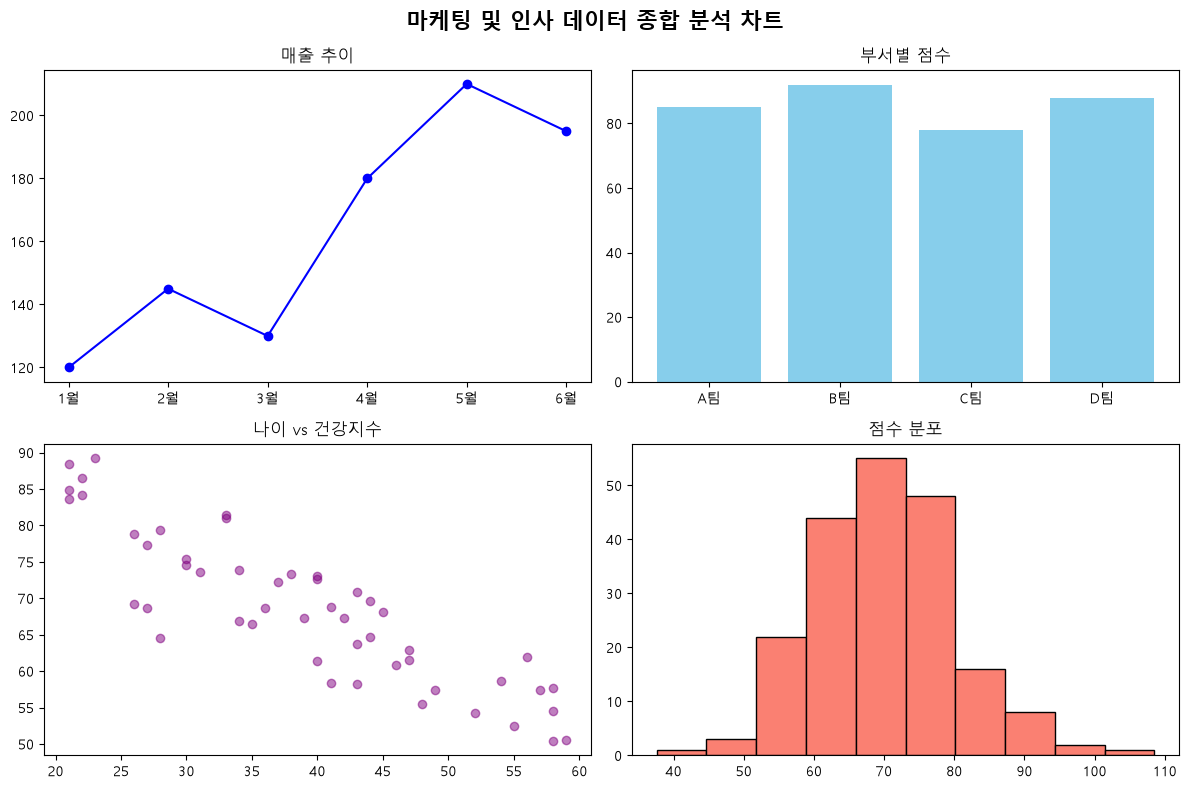

In [8]:
# 3. 한 화면에 여러 그래프 그리기 (Subplots)
# 실무에서는 대시보드 형태로 여러 차트를 한눈에 비교할 때 plt.subplots()를 자주 활용합니다.

# 2행 2열 구조의 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1행 1열 (왼쪽 위)
axes[0, 0].plot(months, sales, 'b-o')
axes[0, 0].set_title('매출 추이')

# 1행 2열 (오른쪽 위)
axes[0, 1].bar(categories, scores, color='skyblue')
axes[0, 1].set_title('부서별 점수')

# 2행 1열 (왼쪽 아래)
axes[1, 0].scatter(age, health_index, color='purple', alpha=0.5)
axes[1, 0].set_title('나이 vs 건강지수')

# 2행 2열 (오른쪽 아래)
axes[1, 1].hist(exam_scores, bins=10, color='salmon', edgecolor='black')
axes[1, 1].set_title('점수 분포')

# 레이아웃 겹침 방지 및 전체 타이틀 설정
plt.suptitle('마케팅 및 인사 데이터 종합 분석 차트', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()